#  Gaussian Process Classification
**Cancer Diagnosis with Probabilistic Uncertainty**



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, ConstantKernel as C
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# Load Breast Cancer Wisconsin Dataset
data = load_breast_cancer()
X = data.data
y = data.target  # 0 = malignant, 1 = benign

In [3]:


# Train-test split
X_train, X_t, y_train, y_t = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_t, y_t, test_size=0.5, random_state=42, stratify=y_t)


# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset shape: {X.shape}")
print(f"Train samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")
print(f"Class distribution (train): Malignant={sum(y_train==0)}, Benign={sum(y_train==1)}")
print(f"Features: {data.feature_names[:5]}... (30 total)")

Dataset shape: (569, 30)
Train samples: 398, Validation samples: 85, Test samples: 86
Class distribution (train): Malignant=148, Benign=250
Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']... (30 total)


In [4]:
# Define different kernel configurations
kernels = {
    'RBF': C(1.0) * RBF(length_scale=1.0),
    'Matérn': C(1.0) * Matern(length_scale=1.0, nu=1.5),
    'RationalQuadratic': C(1.0) * RationalQuadratic(length_scale=1.0, alpha=1.0)
}

# Train models
models = {}
predictions = {}
probabilities = {}

for name, kernel in kernels.items():
    print(f"\nTraining GPC with {name} kernel...")
    
    gpc = GaussianProcessClassifier(
        kernel=kernel,
        n_restarts_optimizer=10,
        random_state=42,
        max_iter_predict=100
    )
    
    gpc.fit(X_train_scaled, y_train)
    
    # Predictions and probabilities
    y_pred = gpc.predict(X_test_scaled)
    y_proba = gpc.predict_proba(X_test_scaled)
    
    models[name] = gpc
    predictions[name] = y_pred
    probabilities[name] = y_proba
    
    print(f"Optimized kernel: {gpc.kernel_}")
    print(f"Log-marginal-likelihood: {gpc.log_marginal_likelihood(gpc.kernel_.theta):.2f}")


Training GPC with RBF kernel...
Optimized kernel: 18.9**2 * RBF(length_scale=10.1)
Log-marginal-likelihood: -45.55

Training GPC with Matérn kernel...
Optimized kernel: 31.6**2 * Matern(length_scale=34.8, nu=1.5)
Log-marginal-likelihood: -46.99

Training GPC with RationalQuadratic kernel...
Optimized kernel: 18.9**2 * RationalQuadratic(alpha=1e+05, length_scale=10.1)
Log-marginal-likelihood: -45.55


In [5]:
# Evaluation
print("\n" + "="*70)
print("MODEL EVALUATION - Breast Cancer Classification")
print("="*70)

for name in kernels.keys():
    y_pred = predictions[name]
    y_proba = probabilities[name]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba[:, 1])
    
    # Malignant recall (critical metric for cancer)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    malignant_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # Uncertainty quantification: mean prediction confidence
    mean_confidence = np.mean(np.max(y_proba, axis=1))
    uncertain_cases = np.sum((np.max(y_proba, axis=1) < 0.7))  # Cases with <70% confidence
    
    print(f"\n{name} Kernel:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall (Benign):     {rec:.4f}")
    print(f"  Recall (Malignant):  {malignant_recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    print(f"  Mean confidence: {mean_confidence:.2%}")
    print(f"  Uncertain cases (<70% confidence): {uncertain_cases}/{len(y_test)}")

print("\n" + "="*70)


MODEL EVALUATION - Breast Cancer Classification

RBF Kernel:
  Accuracy:  0.9884
  Precision: 0.9818
  Recall (Benign):     1.0000
  Recall (Malignant):  1.0000
  F1-Score:  0.9908
  ROC-AUC:   0.9948
  Mean confidence: 91.00%
  Uncertain cases (<70% confidence): 10/86

Matérn Kernel:
  Accuracy:  0.9884
  Precision: 0.9818
  Recall (Benign):     1.0000
  Recall (Malignant):  1.0000
  F1-Score:  0.9908
  ROC-AUC:   0.9954
  Mean confidence: 91.50%
  Uncertain cases (<70% confidence): 7/86

RationalQuadratic Kernel:
  Accuracy:  0.9884
  Precision: 0.9818
  Recall (Benign):     1.0000
  Recall (Malignant):  1.0000
  F1-Score:  0.9908
  ROC-AUC:   0.9948
  Mean confidence: 91.00%
  Uncertain cases (<70% confidence): 10/86



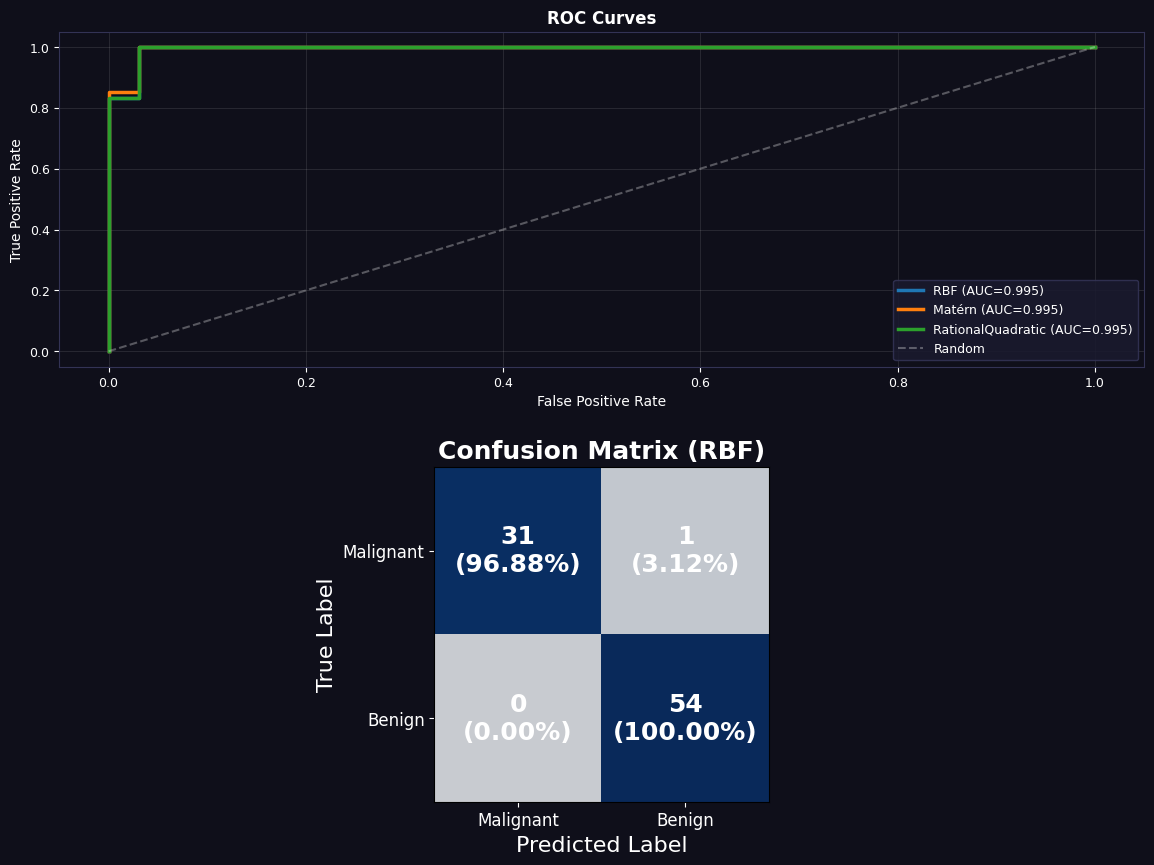

In [6]:
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#0f0f1a')
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.3, wspace=0.3)

colors = plt.cm.tab10.colors
best_model = list(kernels.keys())[0]

# Plot 1: ROC Curve (all kernels)
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#0f0f1a')

for name, color in zip(kernels.keys(), colors[:3]):
    y_proba = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
    auc = roc_auc_score(y_test, y_proba[:, 1])
    ax1.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC={auc:.3f})')

ax1.plot([0, 1], [0, 1], '--', color='white', alpha=0.3, linewidth=1.5, label='Random')
ax1.set_title('ROC Curves', color='white', fontsize=12, fontweight='bold')
ax1.set_xlabel('False Positive Rate', color='white', fontsize=10)
ax1.set_ylabel('True Positive Rate', color='white', fontsize=10)
ax1.tick_params(colors='white', labelsize=9)
ax1.spines['bottom'].set_color('#333355')
ax1.spines['top'].set_color('#333355')
ax1.spines['left'].set_color('#333355')
ax1.spines['right'].set_color('#333355')
ax1.grid(True, alpha=0.1, color='white')

legend = ax1.legend(loc='lower right', framealpha=0.9, fontsize=9)
legend.get_frame().set_facecolor('#1a1a2e')
legend.get_frame().set_edgecolor('#333355')
for text in legend.get_texts():
    text.set_color('white')

# Plot 2: Confusion Matrix (best model)
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#0f0f1a')

cm = confusion_matrix(y_test, predictions[best_model])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

im = ax2.imshow(cm_norm, interpolation='nearest', cmap='Blues', alpha=0.8)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(j, i, f'{cm[i, j]}\n({cm_norm[i, j]:.2%})',
                ha="center", va="center", color="white", fontsize=18, fontweight='bold')

ax2.set_title(f'Confusion Matrix ({best_model})', color='white', fontsize=18, fontweight='bold')
ax2.set_ylabel('True Label', color='white', fontsize=16)
ax2.set_xlabel('Predicted Label', color='white', fontsize=16)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Malignant', 'Benign'])
ax2.set_yticklabels(['Malignant', 'Benign'])
ax2.tick_params(colors='white', labelsize=12)